# Feature Extraction

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

from glob import glob

import librosa
import librosa.display 
import IPython.display as ipd

from itertools import cycle

sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

### Reading audio files - Load sample audio from each class

In [2]:
Audio_files = glob('../../data/raw/*/*/*/1.wav')

In [9]:
y_machine1_normal, sr_machine1_normal = librosa.load(Audio_files[1])
y_machine1_abnormal, sr_machine1_abnormal = librosa.load(Audio_files[0])

y_machine2_normal, sr_machine2_normal = librosa.load(Audio_files[3])
y_machine2_abnormal, sr_machine2_abnormal = librosa.load(Audio_files[2])

y_machine3_normal, sr_machine3_normal = librosa.load(Audio_files[5])
y_machine3_abnormal, sr_machine3_abnormal = librosa.load(Audio_files[4])

print(f'y_machine1_normal: {y_machine1_normal[:10]}')
print(f'shape of y_machine1_normal: {y_machine1_normal.shape}')
print(f'sr_machine1_normal: {sr_machine1_normal}')

print(f'y_machine1_abnormal: {y_machine1_abnormal[:10]}')
print(f'shape of y_machine1_abnormal: {y_machine1_abnormal.shape}')
print(f'sr_machine1_abnormal: {sr_machine1_abnormal}')

y_machine1_normal: [2.67602245e-05 1.80905809e-05 3.12137649e-06 1.02156755e-05
 8.88189152e-06 2.99257190e-05 9.51542825e-06 1.93819687e-05
 1.10195424e-05 3.03830166e-05]
shape of y_machine1_normal: (242550,)
sr_machine1_normal: 22050
y_machine1_abnormal: [ 2.5960995e-05  4.0425646e-05  2.0044372e-05  2.2074710e-05
  2.9475373e-06  1.1690736e-05  1.7469611e-05 -3.7975192e-06
  3.3969511e-05  3.8920130e-05]
shape of y_machine1_abnormal: (242550,)
sr_machine1_abnormal: 22050


In [4]:
# Normal
ipd.Audio(Audio_files[1])

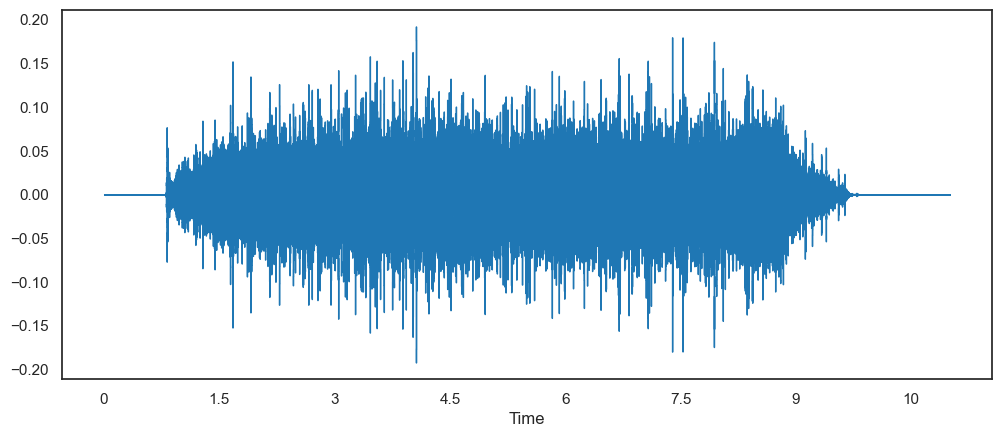

In [5]:
plt.figure().set_figwidth(12)
librosa.display.waveshow(y_machine1_normal, sr=sr_machine1_normal)

In [ ]:
# Abnormal
ipd.Audio(Audio_files[0])

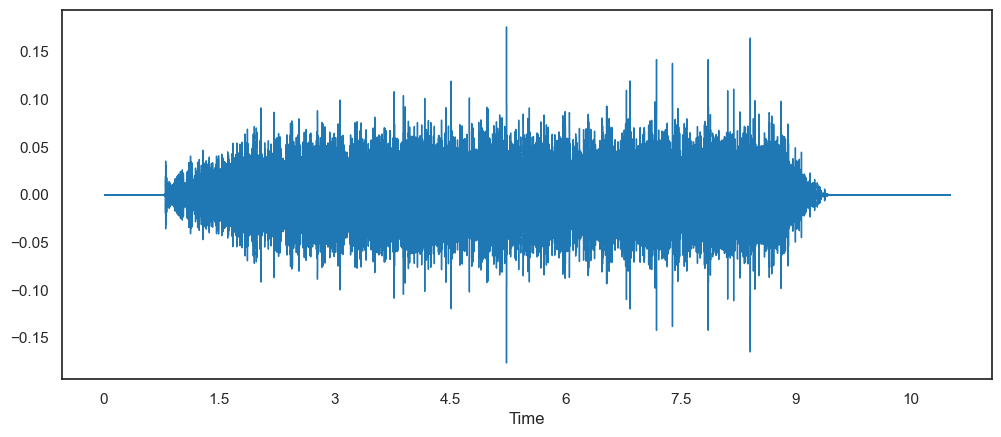

In [ ]:
plt.figure().set_figwidth(12)
librosa.display.waveshow(y_machine1_abnormal, sr=sr_machine1_abnormal)

## Extract MFCC

In [14]:
mfcc_normal_1 = librosa.feature.mfcc(y=y_machine1_normal, sr=sr_machine1_normal, n_mfcc=13)
mfcc_abnormal_1 = librosa.feature.mfcc(y=y_machine1_abnormal, sr=sr_machine1_abnormal, n_mfcc=13)

mfcc_normal_2 = librosa.feature.mfcc(y=y_machine2_normal, sr=sr_machine2_normal, n_mfcc=13)
mfcc_abnormal_2 = librosa.feature.mfcc(y=y_machine2_abnormal, sr=sr_machine2_abnormal, n_mfcc=13)

mfcc_normal_3 = librosa.feature.mfcc(y=y_machine3_normal, sr=sr_machine3_normal, n_mfcc=13)
mfcc_abnormal_3 = librosa.feature.mfcc(y=y_machine3_abnormal, sr=sr_machine3_abnormal, n_mfcc=13)

print(mfcc_normal_1.shape)
print(mfcc_abnormal_1.shape)

print(mfcc_normal_2.shape)
print(mfcc_abnormal_2.shape)

print(mfcc_normal_3.shape)
print(mfcc_abnormal_3.shape)

(13, 474)
(13, 474)
(13, 474)
(13, 474)
(13, 431)
(13, 431)


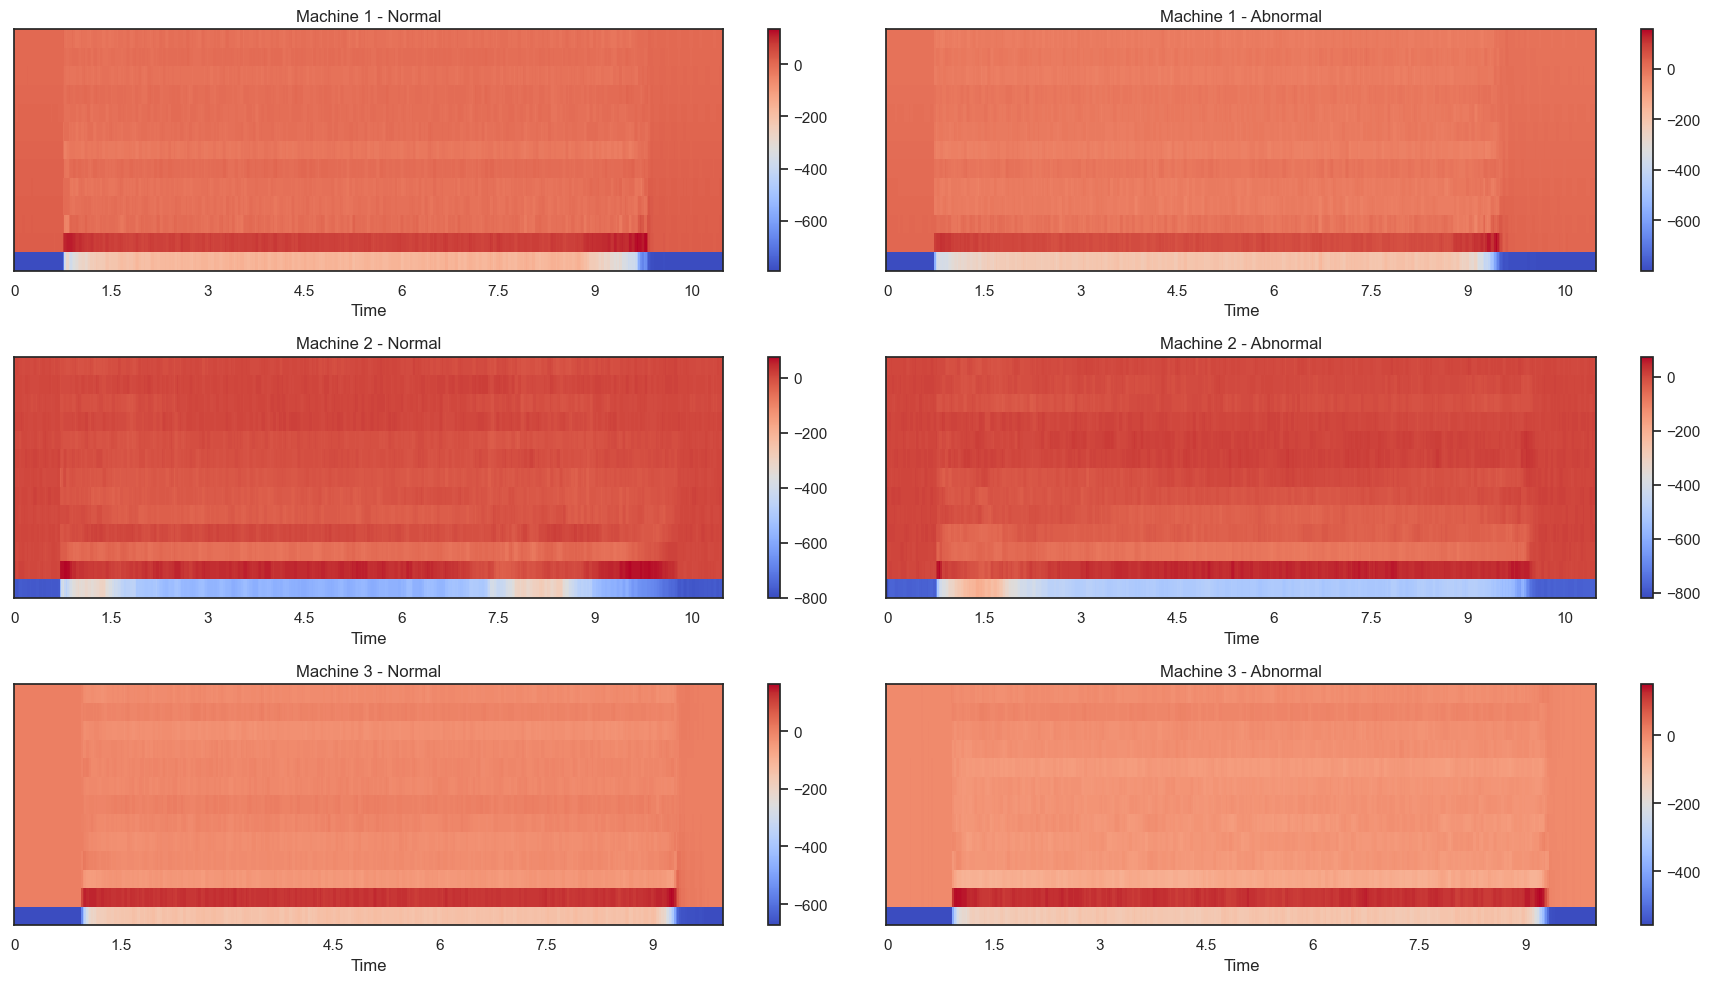

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

# Machine 1
img1 = librosa.display.specshow(
    mfcc_normal_1, x_axis='time', sr=sr_machine1_normal, ax=axes[0, 0]
)
axes[0, 0].set_title('Machine 1 - Normal')
fig.colorbar(img1, ax=axes[0, 0])

img2 = librosa.display.specshow(
    mfcc_abnormal_1, x_axis='time', sr=sr_machine1_abnormal, ax=axes[0, 1]
)
axes[0, 1].set_title('Machine 1 - Abnormal')
fig.colorbar(img2, ax=axes[0, 1])

# Machine 2
img3 = librosa.display.specshow(
    mfcc_normal_2, x_axis='time', sr=sr_machine2_normal, ax=axes[1, 0]
)
axes[1, 0].set_title('Machine 2 - Normal')
fig.colorbar(img3, ax=axes[1, 0])

img4 = librosa.display.specshow(
    mfcc_abnormal_2, x_axis='time', sr=sr_machine2_abnormal, ax=axes[1, 1]
)
axes[1, 1].set_title('Machine 2 - Abnormal')
fig.colorbar(img4, ax=axes[1, 1])

# Machine 3
img5 = librosa.display.specshow(
    mfcc_normal_3, x_axis='time', sr=sr_machine3_normal, ax=axes[2, 0]
)
axes[2, 0].set_title('Machine 3 - Normal')
fig.colorbar(img5, ax=axes[2, 0])

img6 = librosa.display.specshow(
    mfcc_abnormal_3, x_axis='time', sr=sr_machine3_abnormal, ax=axes[2, 1]
)
axes[2, 1].set_title('Machine 3 - Abnormal')
fig.colorbar(img6, ax=axes[2, 1])

plt.tight_layout()
plt.show()

In [ ]:
def extract_mfcc(audio, sr, n_mfcc=13):
    return librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

def add_mfcc_stats(mfcc):

    mean = mfcc.mean(axis=1)
    std = mfcc.std(axis=1)

    return np.concatenate([mean, std])

def add_mfcc_stats_with_deltas(mfcc):
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    features = np.concatenate([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        delta.mean(axis=1), delta.std(axis=1),
        delta2.mean(axis=1), delta2.std(axis=1)
    ])

    return features